# 01 · Modelo #4 — Segmentación de clientes por valor (CLV)

**Caso de uso 5** · **Sector:** Banca · **Analítica:** Clustering · **Solo ACH:** Sí
**Metodología:** CRISP-DM · Fases 3–4 · **Depende de:** `00_EDA_Preparacion_Datos.ipynb`

### Objetivo de negocio
Agrupar a las personas por su **valor transaccional** para que un banco identifique a sus clientes más
valiosos (retención, cross-sell) y a los de bajo valor o en fuga. Se construye un **CLV-proxy** sobre la señal
que ACH observa: dinero **realmente** movido (recibido + enviado + gasto PSE), frecuencia, permanencia y
recencia — enriquecido con el **ingreso declarado** (IBC de Seguridad Social).

**Empresas objetivo:** Bancolombia, Davivienda, Banco de Bogotá, BBVA Colombia, Nequi, Daviplata,
Banco Popular, Banco Caja Social, Lulo Bank.

### Novedades de esta iteración
- **Llave por cédula** → cruza las 3 fuentes (entra el IBC declarado como feature).
- **Cuenta propia excluida:** las transferencias entre cuentas de la misma persona **no** cuentan como
  ingreso ni gasto (antes inflaban el valor).
- **K = 4** para segmentos más específicos (alto valor formal vs informal, gastador solo PSE, bajo valor).

> ⚠️ Limitaciones: truncamiento de Transferencias/PSE (volúmenes relativos, no censales); sin campo de ciudad.

## 1 · Configuración

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

ROOT = Path.cwd()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "scripts"))
import ach_pipeline as ap   # noqa: E402

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (11, 4.2),
                     "axes.titlesize": 12, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
RNG = 0
cop = mticker.FuncFormatter(lambda x, _: f"${x/1e6:,.1f}M")
print("Listo")

Listo


## 2 · Construcción de features (nivel persona)

`ap.build_clv_features()` arma la tabla persona × features de valor desde las 3 fuentes cruzadas por cédula.

In [2]:
clv = ap.build_clv_features()
print(f"Personas: {len(clv):,}")
cols_modelo = ["recibido_total", "enviado_total", "gasto_total", "throughput",
               "n_transacciones", "meses_activos", "recencia_meses",
               "transfiya_share", "gasto_financiero_share", "ibc_ss", "clv_proxy"]
display(clv[cols_modelo].describe(percentiles=[.25, .5, .75, .95]).T)
print("Composición por tipo de persona (SS):")
print(clv["tipo_persona"].value_counts().to_string())

Personas: 32,164


,count,mean,std,min,25%,50%,75%,95%,max
recibido_total,"32,164.00","13,664,247.69","48,759,300.63",0.00,"127,425.00","2,245,999.50","11,821,603.75","62,041,441.10","5,075,498,425.00"
enviado_total,"32,164.00","3,168,551.29","15,035,085.29",0.00,0.00,"233,000.00","2,450,100.00","13,358,190.00","1,021,870,600.00"
gasto_total,"32,164.00","13,238,036.29","34,584,544.89",0.00,"543,541.75","3,424,175.08","12,715,026.75","54,913,112.04","1,233,054,460.40"
throughput,"32,164.00","30,070,835.27","72,359,797.36",0.00,"3,254,595.27","11,889,410.46","33,273,904.75","112,152,143.12","5,916,765,925.00"
n_transacciones,"32,164.00",99.06,134.42,0.00,24.00,61.00,129.00,307.00,"4,072.00"
meses_activos,"32,164.00",12.60,5.26,1.00,9.00,14.00,18.00,18.00,18.00
recencia_meses,"32,164.00",1.25,3.00,0.00,0.00,0.00,1.00,9.00,17.00
transfiya_share,"32,164.00",0.35,0.41,0.00,0.00,0.10,0.84,1.00,1.00
gasto_financiero_share,"32,164.00",0.23,0.30,0.00,0.00,0.07,0.42,0.86,1.00
ibc_ss,"32,164.00","1,131,867.02","1,587,571.06",0.00,0.00,"1,212,467.00","1,600,000.00","3,090,917.10","35,587,500.00"


Composición por tipo de persona (SS):
tipo_persona
Empleado         21017
Sin PILA          7611
Independiente     2311
Aprendiz           803
Pensionado         237
Magisterio         185


### 2.1 · Distribuciones

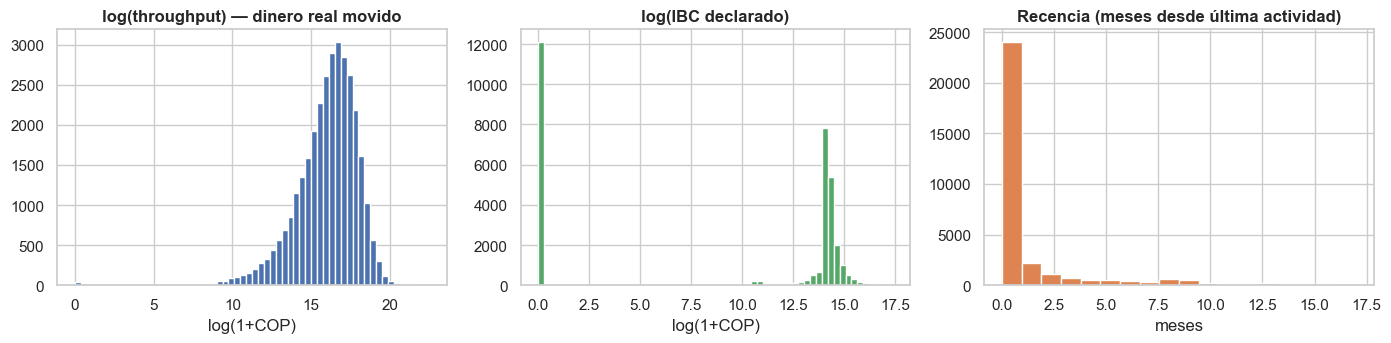

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
axes[0].hist(np.log1p(clv["throughput"]), bins=60, color="#4c72b0", edgecolor="white")
axes[0].set_title("log(throughput) — dinero real movido"); axes[0].set_xlabel("log(1+COP)")
axes[1].hist(np.log1p(clv["ibc_ss"]), bins=60, color="#55a868", edgecolor="white")
axes[1].set_title("log(IBC declarado)"); axes[1].set_xlabel("log(1+COP)")
axes[2].hist(clv["recencia_meses"], bins=18, color="#dd8452", edgecolor="white")
axes[2].set_title("Recencia (meses desde última actividad)"); axes[2].set_xlabel("meses")
plt.tight_layout(); plt.show()

## 3 · Preprocesamiento
Montos y conteos con `log1p`; estandarización con `StandardScaler`.

In [4]:
feat_log = ["recibido_total", "enviado_total", "gasto_total", "throughput",
            "n_transacciones", "ibc_ss", "clv_proxy"]
X = clv[cols_modelo].copy()
for c in feat_log:
    X[c] = np.log1p(X[c])
Xs = StandardScaler().fit_transform(X.fillna(0.0))
print("Matriz de modelado:", Xs.shape)

Matriz de modelado: (32164, 11)


## 4 · Selección del número de segmentos (k)
Se explora **k ≥ 4**: k=2–3 maximizan la silueta pero son cortes gruesos; el negocio pide segmentos más
específicos, así que se parte de 4.

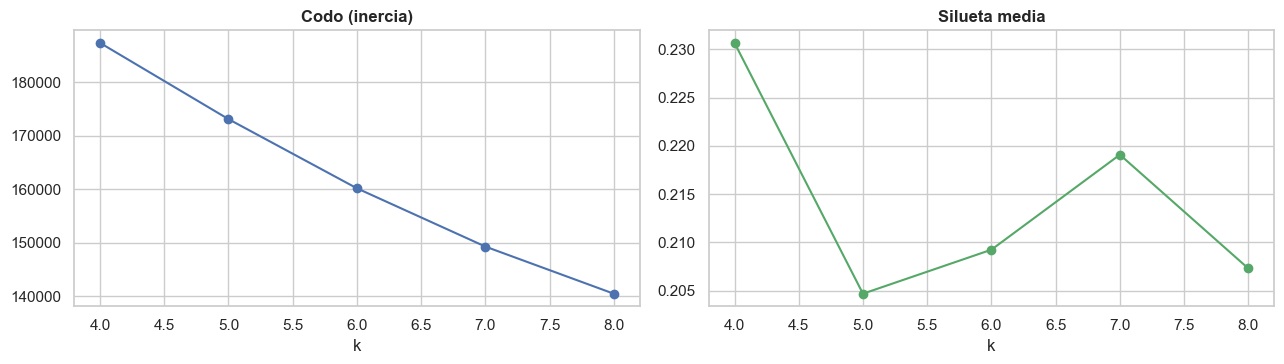

k con mejor silueta (k>=4): 4  (silueta = 0.231)


In [5]:
ks = range(4, 9)
inercia, sil = [], []
muestra = np.random.RandomState(RNG).choice(len(Xs), min(8000, len(Xs)), replace=False)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RNG).fit(Xs)
    inercia.append(km.inertia_); sil.append(silhouette_score(Xs[muestra], km.labels_[muestra]))
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].plot(list(ks), inercia, "o-", color="#4c72b0"); axes[0].set_title("Codo (inercia)"); axes[0].set_xlabel("k")
axes[1].plot(list(ks), sil, "o-", color="#55a868"); axes[1].set_title("Silueta media"); axes[1].set_xlabel("k")
plt.tight_layout(); plt.show()
K = list(ks)[int(np.argmax(sil))]
print(f"k con mejor silueta (k>=4): {K}  (silueta = {max(sil):.3f})")

## 5 · Segmentación final (K-Means)

In [6]:
km = KMeans(n_clusters=K, n_init=20, random_state=RNG).fit(Xs)
clv["cluster"] = km.labels_
perfil = clv.groupby("cluster").agg(
    personas=("person_id", "size"),
    recibido=("recibido_total", "median"), gasto_pse=("gasto_total", "median"),
    throughput=("throughput", "median"), ibc=("ibc_ss", "median"),
    n_tx=("n_transacciones", "median"), meses_activos=("meses_activos", "median"),
    recencia=("recencia_meses", "median"), clv_proxy=("clv_proxy", "median"))
display(perfil.round(0))

,personas,recibido,gasto_pse,throughput,ibc,n_tx,meses_activos,recencia,clv_proxy
cluster,,,,,,,,,
0,9802,"1,695,938.00","875,704.00","4,826,690.00",0.00,33.00,10.00,0.00,"150,669.00"
1,13617,"13,146,000.00","9,895,754.00","32,566,328.00","1,369,149.00",126.00,17.00,0.00,"1,641,504.00"
2,4100,"10,000.00","60,000.00","407,152.00","525,272.00",5.00,3.00,6.00,"4,272.00"
3,4645,0.00,"12,161,037.00","13,261,311.00","1,400,000.00",62.00,17.00,0.00,"644,107.00"


### 5.1 · Nombres de negocio
Etiqueta por regla sobre el perfil (no por número de cluster). Distingue alto valor **con ingreso formal**
(IBC>0) vs **informal** (sin PILA), gastador solo por PSE, y bajo valor / en fuga.

In [7]:
def _es_pse(r):  return r["gasto_pse"] > 0 and r["recibido"] < 0.15 * r["gasto_pse"]
def _es_fuga(r): return r["recencia"] >= 2 or r["meses_activos"] <= 6

# Clusters "activos" (ni solo-PSE ni en fuga), ordenados por throughput:
# el de mayor volumen es el de ALTO valor; el resto, valor medio.
activos = [cl for cl in perfil.index if not _es_pse(perfil.loc[cl]) and not _es_fuga(perfil.loc[cl])]
orden = perfil.loc[activos].sort_values("throughput", ascending=False).index.tolist()

def nombrar(cl):
    r = perfil.loc[cl]
    if _es_pse(r):
        return "Gastador digital (solo PSE)"
    if _es_fuga(r):
        return "Bajo valor / en fuga"
    nivel = "Alto valor" if orden and cl == orden[0] else "Valor medio"
    return f"{nivel} · {'ingreso formal' if r['ibc'] > 0 else 'informal'}"

nombres = {cl: nombrar(cl) for cl in perfil.index}
vistos = {}
for cl in perfil.sort_values("throughput", ascending=False).index:
    n = nombres[cl]
    if n in vistos.values():
        n = f"{n} ({perfil.loc[cl, 'personas']:,})"
    vistos[cl] = n
clv["segmento"] = clv["cluster"].map(vistos)
perfil["segmento"] = perfil.index.map(vistos)
display(perfil.set_index("segmento").round(0))

,personas,recibido,gasto_pse,throughput,ibc,n_tx,meses_activos,recencia,clv_proxy
segmento,,,,,,,,,
Valor medio · informal,9802,"1,695,938.00","875,704.00","4,826,690.00",0.00,33.00,10.00,0.00,"150,669.00"
Alto valor · ingreso formal,13617,"13,146,000.00","9,895,754.00","32,566,328.00","1,369,149.00",126.00,17.00,0.00,"1,641,504.00"
Bajo valor / en fuga,4100,"10,000.00","60,000.00","407,152.00","525,272.00",5.00,3.00,6.00,"4,272.00"
Gastador digital (solo PSE),4645,0.00,"12,161,037.00","13,261,311.00","1,400,000.00",62.00,17.00,0.00,"644,107.00"


## 6 · Visualización

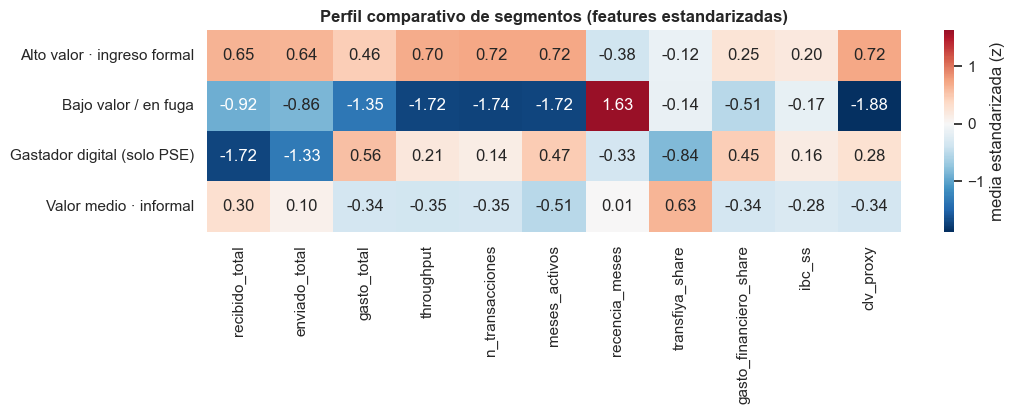

In [8]:
Xstd = pd.DataFrame(Xs, columns=cols_modelo); Xstd["segmento"] = clv["segmento"].values
heat = Xstd.groupby("segmento").mean()
fig, ax = plt.subplots(figsize=(11, 0.7 * len(heat) + 1.5))
sns.heatmap(heat, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "media estandarizada (z)"})
ax.set_title("Perfil comparativo de segmentos (features estandarizadas)"); ax.set_ylabel("")
plt.tight_layout(); plt.show()

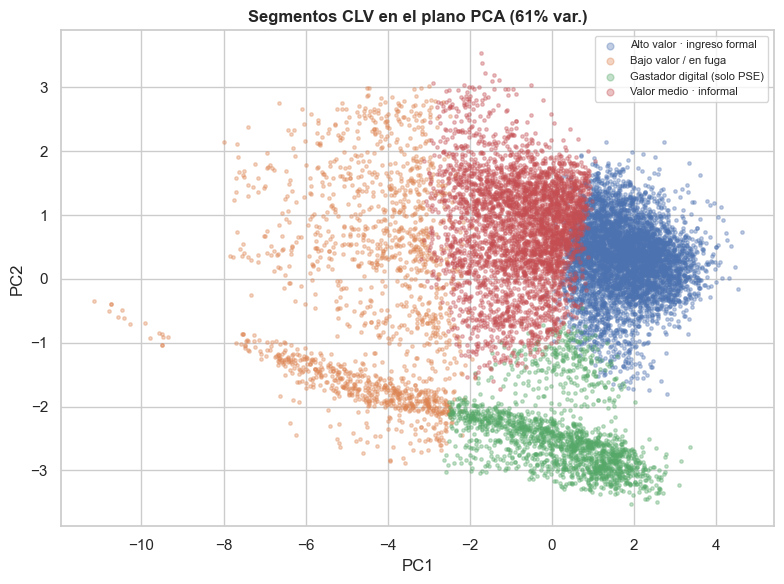

In [9]:
pca = PCA(n_components=2, random_state=RNG).fit(Xs); proj = pca.transform(Xs)
idx = np.random.RandomState(RNG).choice(len(proj), min(12000, len(proj)), replace=False)
fig, ax = plt.subplots(figsize=(8, 6))
for seg in sorted(clv["segmento"].unique()):
    m = (clv["segmento"].values == seg)[idx]
    ax.scatter(proj[idx][m, 0], proj[idx][m, 1], s=6, alpha=.35, label=seg)
ax.set_title(f"Segmentos CLV en el plano PCA ({pca.explained_variance_ratio_.sum():.0%} var.)")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(markerscale=2, fontsize=8)
plt.tight_layout(); plt.show()

### 6.1 · Formalidad por segmento
Qué tan formal es cada segmento (composición por tipo de persona de Seguridad Social).

In [10]:
comp = (pd.crosstab(clv["segmento"], clv["tipo_persona"], normalize="index") * 100).round(1)
display(comp)

tipo_persona,Aprendiz,Empleado,Independiente,Magisterio,Pensionado,Sin PILA
segmento,,,,,,
Alto valor · ingreso formal,2.30,71.00,9.60,0.60,0.90,15.70
Bajo valor / en fuga,3.00,59.40,4.60,0.40,0.60,31.90
Gastador digital (solo PSE),1.80,76.90,7.10,1.50,0.90,11.80
Valor medio · informal,2.90,54.50,5.00,0.20,0.50,36.90


## 7 · Perfilamiento comercial: ¿con qué banco opera cada segmento?
Con el decodificador de `Entidad autorizadora` (solo pagos con banco identificable).

In [11]:
pse_raw = ap.add_person_key(ap.load_raw("pse").drop_duplicates(), "pse")
ent = ap.decode_entidad_autorizadora(pse_raw["Entidad autorizadora"])
pse_raw = pse_raw.assign(entidad=ent["entidad"].values, conf=ent["entidad_confianza"].values)
pse_raw = pse_raw.merge(clv[["person_id", "segmento"]], on="person_id", how="inner")
usable = pse_raw[pse_raw["conf"].isin(["alta", "media"])]
top = (usable.groupby(["segmento", "entidad"]).size().rename("n").reset_index()
       .sort_values(["segmento", "n"], ascending=[True, False]))
for seg in sorted(usable["segmento"].unique()):
    t = top[top["segmento"] == seg].head(4)
    print(f"{seg:32} -> " + " · ".join(f"{r.entidad} ({r.n:,})" for r in t.itertuples()))

Alto valor · ingreso formal      -> BANCOLOMBIA (136,169) · DAVIVIENDA (60,465) · DAVIPLATA (46,277) · BBVA COLOMBIA (22,961)
Bajo valor / en fuga             -> BANCOLOMBIA (1,625) · DAVIPLATA (705) · DAVIVIENDA (296) · BBVA COLOMBIA (206)
Gastador digital (solo PSE)      -> BANCOLOMBIA (58,194) · BBVA COLOMBIA (34,001) · DAVIVIENDA (33,800) · DAVIPLATA (13,395)
Valor medio · informal           -> BANCOLOMBIA (14,282) · DAVIPLATA (7,018) · DAVIVIENDA (2,423) · BBVA COLOMBIA (620)


## 8 · Valor por segmento y conclusiones

,personas,clv_total,clv_medio,throughput_medio,%_personas,%_clv_total
segmento,,,,,,
Alto valor · ingreso formal,13617,"39,033,253,641.00","1,641,504.00","32,566,328.00",42.00,79.00
Gastador digital (solo PSE),4645,"8,265,569,482.00","644,107.00","13,261,311.00",14.00,17.00
Valor medio · informal,9802,"2,207,870,717.00","150,669.00","4,826,690.00",30.00,4.00
Bajo valor / en fuga,4100,"53,309,224.00","4,272.00","407,152.00",13.00,0.00


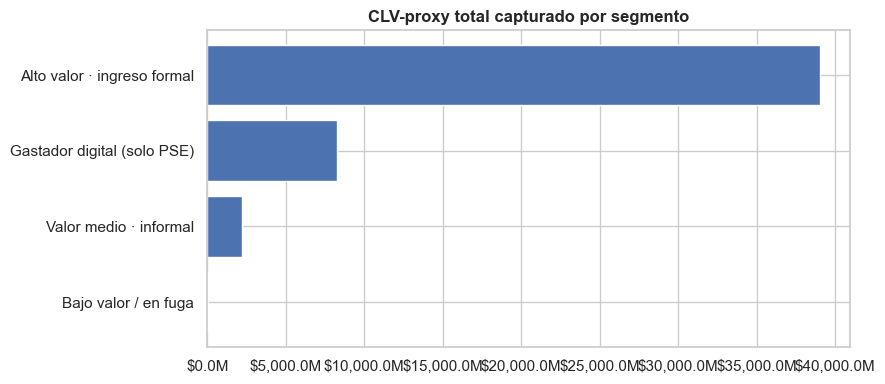

In [12]:
resumen = clv.groupby("segmento").agg(
    personas=("person_id", "size"), clv_total=("clv_proxy", "sum"),
    clv_medio=("clv_proxy", "median"), throughput_medio=("throughput", "median"))
resumen["%_personas"] = (resumen["personas"] / len(clv) * 100).round(1)
resumen["%_clv_total"] = (resumen["clv_total"] / resumen["clv_total"].sum() * 100).round(1)
display(resumen.sort_values("clv_total", ascending=False).round(0))
fig, ax = plt.subplots(figsize=(9, 4)); r = resumen.sort_values("clv_total")
ax.barh(r.index, r["clv_total"], color="#4c72b0")
ax.set_title("CLV-proxy total capturado por segmento"); ax.xaxis.set_major_formatter(cop)
plt.tight_layout(); plt.show()

### Lectura de negocio y acción

- **Alto valor · ingreso formal** — clientes premium con salario declarado alto: retención prioritaria,
  inversión y crédito de alto cupo.
- **Alto valor · informal** — mueven mucho pero sin ingreso formal declarado: candidatos a formalización y a
  productos de ingreso variable.
- **Gastador digital (solo PSE)** — gastan mucho por PSE sin transferencias entrantes visibles: captar nómina.
- **Valor medio** — masa estable; automatización y up-sell.
- **Bajo valor / en fuga** — reactivación de bajo costo o des-priorización.

**Próximos pasos:** resolver el truncamiento (volúmenes censales); reponderar el CLV-proxy con márgenes
reales; cruzar con el modelo de ciclo de vida para una matriz **valor × etapa**.

In [13]:
sal = ROOT / "Data" / "processed" / "segmentos_clv.parquet"
clv[["person_id", "cluster", "segmento", "tipo_persona", "clv_proxy", "throughput",
     "ibc_ss", "meses_activos", "recencia_meses"]].to_parquet(sal, index=False)
print("Guardado:", sal)

Guardado: C:\Users\geoff\Desktop\Proyecto IA ACH\Data\processed\segmentos_clv.parquet
